# Proyek Analisis Data: [Bike-sharing-dataset]
- **Nama:** [Ratu Silma Amalia]
- **Email:** [ratusilma123@gmail.com]
- **ID Dicoding:** [Ratu Silma Amalia]

## Menentukan Pertanyaan Bisnis

- tentukan perbedaan jumlah penyewaan terhadap pengguna casual dan pengguna terdaftar (registered) berdasarkan hari kerja, dan hari libur?
- seberapa berpengaruh kecepatan angin, temperatur suhu, tingkat kelembapan, dan cuaca terhadap jumlah penyewaan sepeda?
- bagaimana menyusun strategi permintaan musiman dengan membandingkan nilai pelanggan (casual vs registered) per musim?






## Import Semua Packages/Library yang Digunakan

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

Memuat & menampilkan data dari masing masing dataset

In [18]:
day_df = pd.read_csv('data\day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [19]:
hour_df = pd.read_csv('data\hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**


1.   kolom casual dan registered
* Kita bisa langsung membandingkan apakah jumlah penyewaan sepeda lebih tinggi untuk pengguna casual atau registered pada hari kerja (workingday = 1) atau hari libur (holiday = 1), serta di berbagai musim (season)
2.   kolom season(musim)
*  Pengguna casual mungkin lebih aktif di musim tertentu, seperti musim semi atau panas, sementara pengguna terdaftar cenderung memiliki pola penggunaan yang lebih stabil sepanjang tahun.
3.   kolom workingday dan holiday

*   Pengguna casual mungkin lebih aktif pada hari libur dan akhir pekan, sementara pengguna registered cenderung menyewa lebih sering pada hari kerja.








### Assessing Data

Deteksi Missing Value & Tipe data

In [20]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [21]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


tidak terdapat missing value pada kedua dataset di atas, tetapi ditemukan tipe data yang tidak cocok pada kolom dteday yang seharusnya menggunakan tipe data datetime

Deteksi Duplikasi & incorrect value

In [22]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [23]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [24]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [25]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


tidak ditemukan duplikasi & incorrect value pada kedua dataset

**Insight:**
- tidak ditemukan missing value, duplikasi data, dan incorrect value pada kedua dataset.
- kedua dataset memiliki kolom dteday dengan tipe data object sehingga perlu diperbaiki menjadi tipe data datetime


### Cleaning Data

In [26]:
datetime_column = ["dteday"]
for column in datetime_column:
   day_df[column] = pd.to_datetime(day_df[column])
   hour_df[column] = pd.to_datetime(hour_df[column])

In [27]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [28]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- kita telah memperbaiki kesalahan tipe data pada kolom dteday kedua set yang tadinya object menjadi datetime
- karena tidak terdapat missing value, incorrect value jadi kedua dataset diatas pada proses ini tidak banyak pembersihan data

## Exploratory Data Analysis (EDA)

### Explore day.csv

In [29]:
day_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [30]:
day_df.groupby(by="season").agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "sum"],
    "casual":["max", "min", "mean", "sum"],
    "registered": ["max", "min", "mean", "sum"]
})

instant   cnt                             casual                    \
       nunique   max   min         mean      sum    max  min         mean   
season                                                                      
1          181  7836   431  2604.132597   471348   3155    9   334.928177   
2          184  8362   795  4992.331522   918589   3410  120  1106.097826   
3          188  8714  1115  5644.303191  1061129   3160  118  1202.611702   
4          178  8555    22  4728.162921   841613   3031    2   729.112360   

               registered                            
           sum        max  min         mean     sum  
season                                               
1        60622       5315  416  2269.204420  410726  
2       203522       6456  674  3886.233696  715067  
3       226091       6917  889  4441.691489  835038  
4       129782       6946   20  3999.050562  711831

In [31]:
day_df.groupby(by="holiday").agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "std"],
    "casual":["max", "min", "mean", "std"],
    "registered": ["max", "min", "mean", "std"]
})

instant   cnt                                 casual       \
        nunique   max   min         mean          std    max  min   
holiday                                                             
0           710  8714    22  4527.104225  1929.013947   3410    2   
1            21  7403  1000  3735.000000  2103.350660   3065  117   

                                 registered                                 
                mean         std        max  min         mean          std  
holiday                                                                     
0         841.771831  680.528529       6946   20  3685.332394  1553.704431  
1        1064.714286  860.046809       5172  573  2670.285714  1492.860246

In [32]:
day_df.groupby(by="workingday").agg({
    "instant": "nunique",
    "cnt": ["max", "min", "mean", "sum"],
    "casual":["max", "min", "mean", "sum"],
    "registered": ["max", "min", "mean", "sum"]
})

instant   cnt                            casual                   \
           nunique   max  min         mean      sum    max min         mean   
workingday                                                                    
0              231  8714  605  4330.168831  1000269   3410  54  1371.134199   
1              500  8362   22  4584.820000  2292410   2469   2   606.570000   

                   registered                             
               sum        max  min         mean      sum  
workingday                                                
0           316732       5966  451  2959.034632   683537  
1           303285       6946   20  3978.250000  1989125

In [33]:
day_df.groupby('mnth').agg(
    total_rentals=('cnt', 'sum'),
    avg_rentals=('cnt', 'mean')
).sort_values(by ='total_rentals', ascending=False).reset_index()

,mnth,total_rentals,avg_rentals
0,8,351194,5664.419355
1,6,346342,5772.366667
2,9,345991,5766.516667
3,7,344948,5563.677419
4,5,331686,5349.774194
5,10,322352,5199.225806
6,4,269094,4484.900000
7,11,254831,4247.183333
8,3,228920,3692.258065
9,12,211036,3403.806452


In [34]:
day_df.groupby('season').agg(
    total_rentals=('cnt', 'sum'),
    avg_rentals=('cnt', 'mean')
).sort_values(by ='total_rentals', ascending=False).reset_index()

,season,total_rentals,avg_rentals
0,3,1061129,5644.303191
1,2,918589,4992.331522
2,4,841613,4728.162921
3,1,471348,2604.132597


### Explore hour.csv

In [35]:
hour_df.groupby('hr').agg(
    avg_total_rentals=('cnt', 'mean')
).sort_values(by= 'avg_total_rentals', ascending = False).reset_index()

,hr,avg_total_rentals
0,17,461.452055
1,18,425.510989
2,8,359.011004
3,16,311.983562
4,19,311.523352
5,13,253.661180
6,12,253.315934
7,15,251.233196
8,14,240.949246
9,20,226.030220


In [36]:
correlation_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'cnt']].corr()
correlation_matrix

,temp,atemp,hum,windspeed,weathersit,cnt
temp,1.000000,0.991702,0.126963,-0.157944,-0.120602,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,-0.121583,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,0.591045,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,0.039511,-0.234545
weathersit,-0.120602,-0.121583,0.591045,0.039511,1.000000,-0.297391
cnt,0.627494,0.631066,-0.100659,-0.234545,-0.297391,1.000000


### Explore hour&day

In [37]:
all_df = pd.merge(
    left=hour_df,
    right=day_df,
    how="inner",
    left_on="instant",
    right_on="instant"
)
all_df.head()

,instant,dteday_x,season_x,yr_x,mnth_x,hr,holiday_x,weekday_x,workingday_x,weathersit_x,...,weekday_y,workingday_y,weathersit_y,temp_y,atemp_y,hum_y,windspeed_y,casual_y,registered_y,cnt_y
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [38]:
hour_day_df.groupby(by="dteday_x").agg({
    "instant": "nunique",
    "cnt_x": "sum",
    "cnt_y": "sum"
}).sort_values(by = ['cnt_x','cnt_y'], ascending=[False,False]).reset_index()

NameError: name 'hour_day_df' is not defined

**Insight:**
- pada proses explore data diatas masing masing dataset kita dapat menarik beberapa informasi berupa seberapa banyak jumlah pengguna casual dan registered berdasarkan beberapa kondisi pada kolom seperti musim, hari kerja, dan hari libur
- kita dapat mengetahui rata rata pengguna menyewa sepeda per jamnya


## Visualization & Explanatory Analysis

### Pertanyaan 1:  tentukan perbedaan jumlah penyewaan terhadap pengguna casual dan pengguna terdaftar (registered) berdasarkan hari kerja, dan hari libur?

### jumlah penyewa di hari kerja(1) & hari kerja (0)


In [ ]:
total_rentals_by_workingday = day_df.groupby('workingday')[['casual', 'registered']].sum().reset_index()
total_rentals_by_workingday

,workingday,casual,registered
0,0,316732,683537
1,1,303285,1989125


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


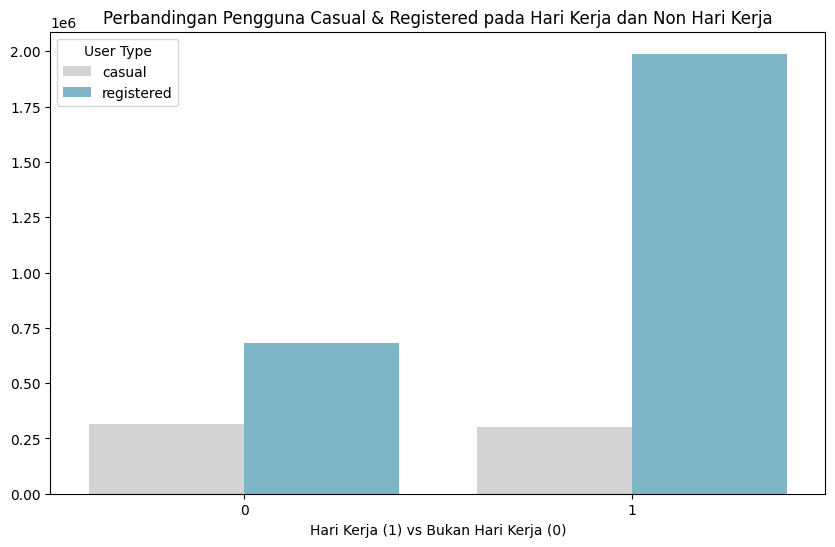

In [ ]:
total_rentals_by_workingday = day_df.groupby('workingday')[['casual', 'registered']].sum().reset_index()

total_rentals_by_workingday_melted = total_rentals_by_workingday.melt(id_vars='workingday', var_name='User Type', value_name='Total Rentals')

plt.figure(figsize=(10, 6))
colors = ["#D3D3D3","#72BCD4" ]

sns.barplot(data=total_rentals_by_workingday_melted, x='workingday', y='Total Rentals', hue='User Type', palette=colors)

plt.title('Perbandingan Pengguna Casual & Registered pada Hari Kerja dan Non Hari Kerja')
plt.xlabel('Hari Kerja (1) vs Bukan Hari Kerja (0)')
plt.ylabel(None)

plt.show()

### jumlah penyewa di hari libur(1) & libur(0)

In [ ]:
total_rentals_by_holiday = day_df.groupby('holiday')[['casual', 'registered']].sum().reset_index()
total_rentals_by_holiday

,holiday,casual,registered
0,0,597658,2616586
1,1,22359,56076


<ipython-input-68-f67341686a16>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_rentals_holiday_days, x='User Type', y='Total Rentals', palette=colors)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


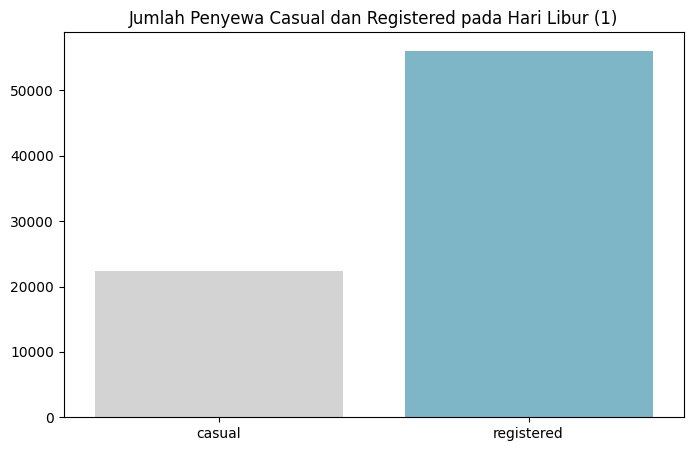

In [ ]:
holiday_days_df = day_df[day_df['holiday'] == 1]

total_rentals_holiday_days = holiday_days_df[['casual', 'registered']].sum().reset_index()
total_rentals_holiday_days.columns = ['User Type', 'Total Rentals']

plt.figure(figsize=(8, 5))
colors = ["#D3D3D3","#72BCD4" ]
sns.barplot(data=total_rentals_holiday_days, x='User Type', y='Total Rentals', palette=colors)


plt.title('Jumlah Penyewa Casual dan Registered pada Hari Libur (1)')
plt.xlabel(None)
plt.ylabel(None)


plt.gca().yaxis.get_major_locator().set_params(integer=True)


plt.show()

<ipython-input-74-bbb8b92c497c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_rentals_holiday_days, x='User Type', y='Total Rentals', palette=colors)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


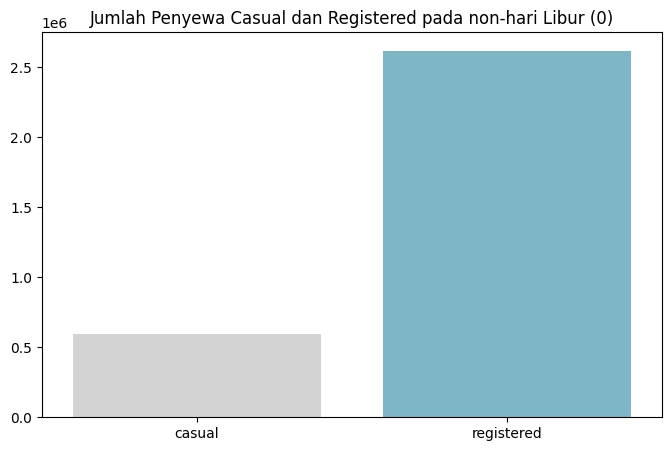

In [ ]:
holiday_days_df = day_df[day_df['holiday'] == 0]

total_rentals_holiday_days = holiday_days_df[['casual', 'registered']].sum().reset_index()
total_rentals_holiday_days.columns = ['User Type', 'Total Rentals']

plt.figure(figsize=(8, 5))
colors = ["#D3D3D3","#72BCD4" ]
sns.barplot(data=total_rentals_holiday_days, x='User Type', y='Total Rentals', palette=colors)


plt.title('Jumlah Penyewa Casual dan Registered pada non-hari Libur (0)')
plt.xlabel(None)
plt.ylabel(None)


plt.gca().yaxis.get_major_locator().set_params(integer=True)


plt.show()

### hari kerja(1) vs hari libur(1)

In [ ]:

workingday_df = day_df[day_df['workingday'] == 1]
holiday_df = day_df[day_df['holiday'] == 1]


workingday_totals = workingday_df[['casual', 'registered']].sum()
holiday_totals = holiday_df[['casual', 'registered']].sum()


comparison_df = pd.DataFrame({
    'Hari Kerja': workingday_totals,
    'Hari Libur': holiday_totals
})

comparison_df

,Hari Kerja,Hari Libur
casual,303285,22359
registered,1989125,56076


/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


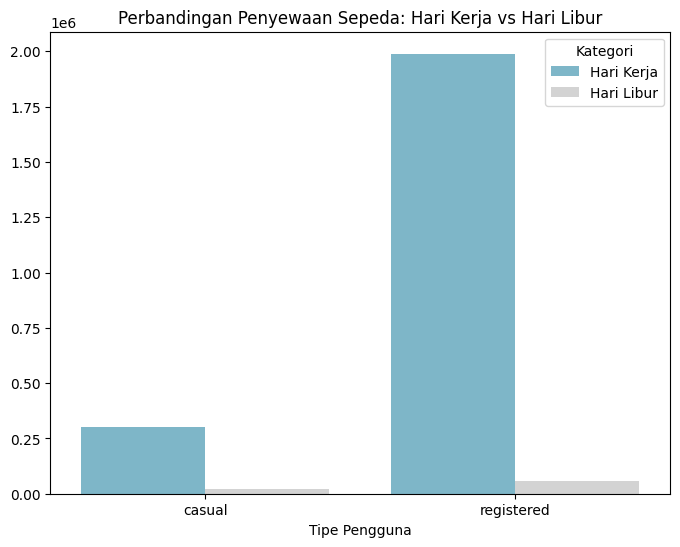

In [ ]:
comparison_melted = comparison_df.reset_index().melt(id_vars='index', var_name='Kategori', value_name='Jumlah Penyewaan')

comparison_melted.rename(columns={'index': 'Tipe Pengguna'}, inplace=True)
colors = ["#72BCD4" , "#D3D3D3"]

plt.figure(figsize=(8, 6))
sns.barplot(data=comparison_melted, x='Tipe Pengguna', y='Jumlah Penyewaan', hue='Kategori', palette=colors)

plt.title('Perbandingan Penyewaan Sepeda: Hari Kerja vs Hari Libur')
plt.xlabel('Tipe Pengguna')
plt.ylabel(None)


plt.show()

**Insight:**
- persamaan yang bisa kita lihat antara pengguna registered dan casual adalah mereka lebih banyak melakukan penyewaan pada saat hari kerja ketimbang hari libur
- sedangkan perbedaan yang bisa ditemukan hanyalah seberapa banyak jumlah penyewaan yang dilakukan antara pengguna casual dan registered berdasarkan hari libur maupun hari kerja


### Pertanyaan 2: seberapa berpengaruh kecepatan angin, temperatur suhu, tingkat kelembapan, dan cuaca terhadap jumlah penyewaan sepeda?

In [ ]:
correlation_matrix = hour_df[['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'cnt']].corr()
correlation_matrix

,temp,atemp,hum,windspeed,weathersit,cnt
temp,1.000000,0.987672,-0.069881,-0.023125,-0.102640,0.404772
atemp,0.987672,1.000000,-0.051918,-0.062336,-0.105563,0.400929
hum,-0.069881,-0.051918,1.000000,-0.290105,0.418130,-0.322911
windspeed,-0.023125,-0.062336,-0.290105,1.000000,0.026226,0.093234
weathersit,-0.102640,-0.105563,0.418130,0.026226,1.000000,-0.142426
cnt,0.404772,0.400929,-0.322911,0.093234,-0.142426,1.000000


### visualisasi suhu vs penyewaan sepeda

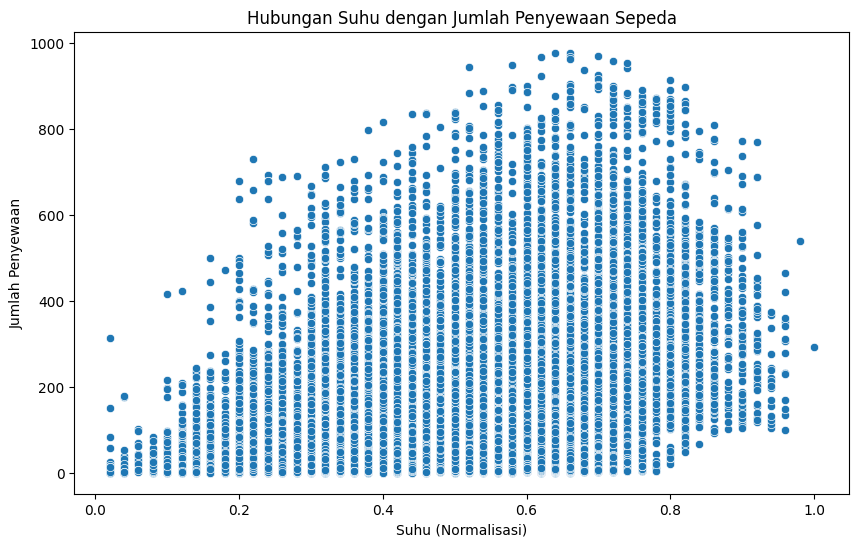

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='temp', y='cnt', data=hour_df)
plt.title('Hubungan Suhu dengan Jumlah Penyewaan Sepeda')
plt.xlabel('Suhu (Normalisasi)')
plt.ylabel('Jumlah Penyewaan')
plt.show()

### visualisasi kelembapan dengan total penyewa

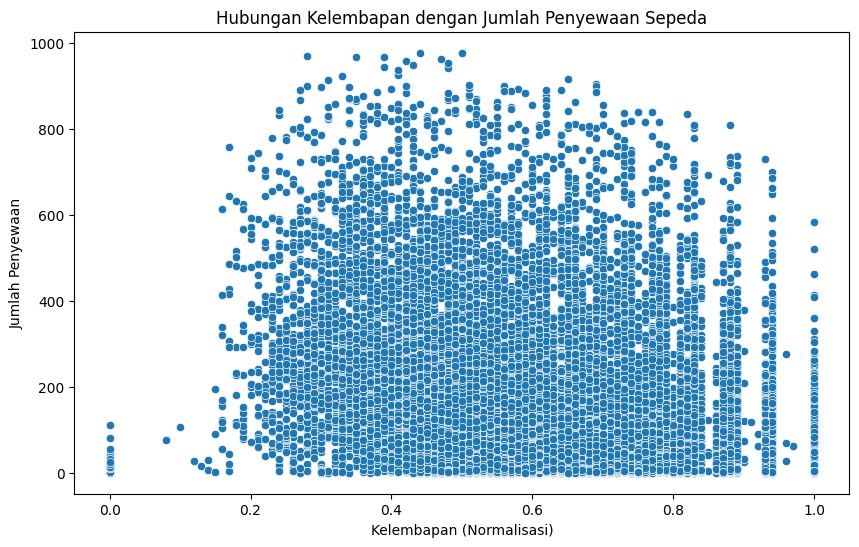

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='hum', y='cnt', data=hour_df)
plt.title('Hubungan Kelembapan dengan Jumlah Penyewaan Sepeda')
plt.xlabel('Kelembapan (Normalisasi)')
plt.ylabel('Jumlah Penyewaan')
plt.show()


### visualisasi kecepatan angin vs total penyewa

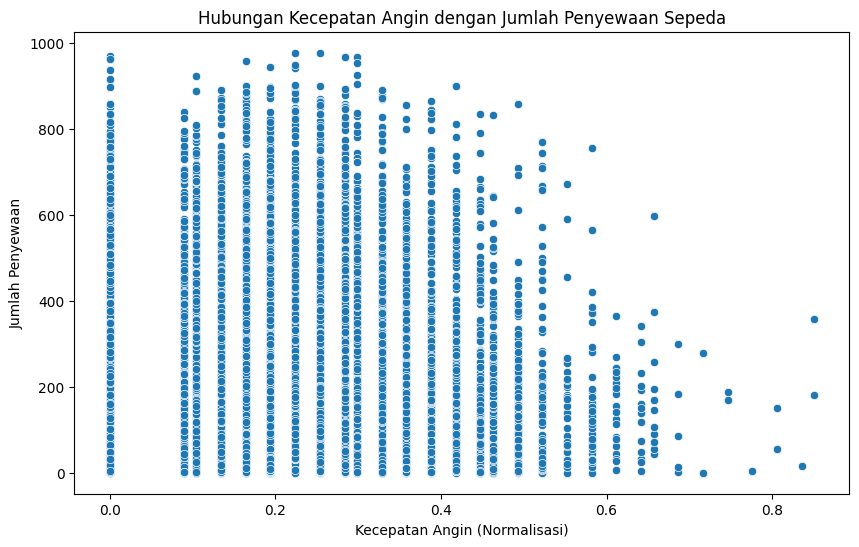

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='windspeed', y='cnt', data=hour_df)
plt.title('Hubungan Kecepatan Angin dengan Jumlah Penyewaan Sepeda')
plt.xlabel('Kecepatan Angin (Normalisasi)')
plt.ylabel('Jumlah Penyewaan')
plt.show()


### visualisasi cuaca vs total penyewa


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


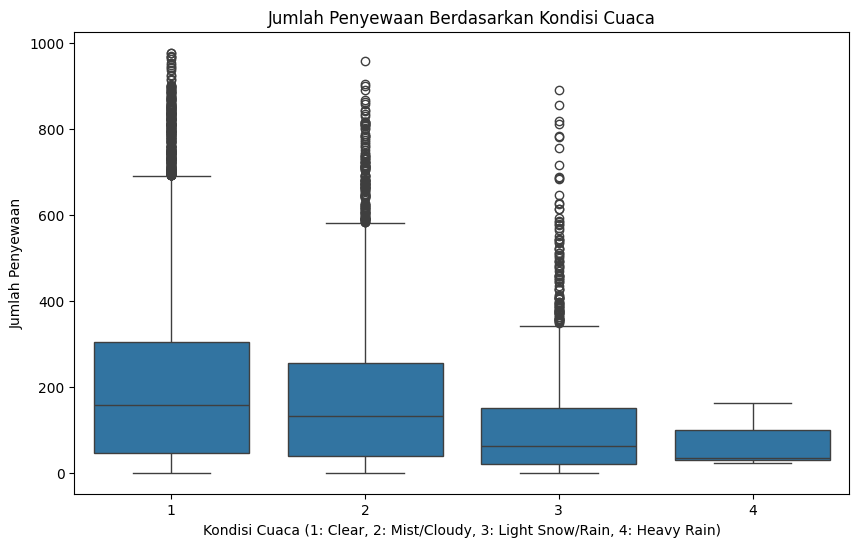

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='weathersit', y='cnt', data=hour_df)
plt.title('Jumlah Penyewaan Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca (1: Clear, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain)')
plt.ylabel('Jumlah Penyewaan')
plt.show()


**Insight:**
- hasil korelasi menunjukkan kekuatan hubungan antara variabel-variabel cuaca dengan total penyewaan sepeda (cnt). korelasi ini memiliki nilai antara -1 hingga 1
- nilai mendekati 1 menunjukkan hubungan positif yang kuat (misalnya, kenaikan suhu alam(temp), suhu yang dirasakan tubuh (atemp) dan kondisi angin (windspeed) dapat menyebabkan lebih banyak penyewa)
- nilai mendekati -1 menunjukkan hubungan negatif (misalnya, kelembaban(hum) dan cuaca(weathersit) yang tinggi memungkinkan menurunkan penyewaan)
- nilai mendekati 0 menunjukkan tidak ada korelasi

## Analisis Lanjutan (Opsional)

### RFM Analysis: Proses dan Tujuan

> **Pertanyaan 3:** bagaimana menyusun strategi permintaan musiman dengan membandingkan nilai pelanggan (casual vs registered) per musim?
> **Definisi RFM:**
- **Recency** = jarak hari dari transaksi terakhir.
- **Frequency** = jumlah hari bertransaksi.
- **Monetary** = total penyewaan (proxy nilai).

**Proses:**
1. Menyiapkan data harian dan mengubah ke format long (per user type per hari).
2. Menghitung RFM per kombinasi musim dan tipe pengguna.
3. Memberi skor R, F, M berbasis kuantil dan membuat segmentasi nilai.
4. Menampilkan tabel ringkas dan visual perbandingan antar musim.

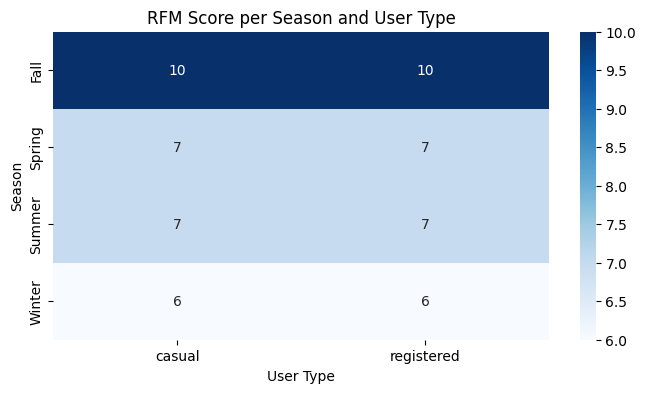

,season_label,user_type,recency_days,frequency,monetary,R,F,M,rfm_score,segment
4,Fall,casual,100,188,226091,2,4,4,10,High Value
5,Fall,registered,100,188,835038,2,4,4,10,High Value


,season_label,user_type,recency_days,frequency,monetary,R,F,M,rfm_score,segment
6,Winter,casual,11,178,129782,3,1,2,6,At Risk
7,Winter,registered,11,178,711831,3,1,2,6,At Risk


In [ ]:
# RFM analysis by season and user type (casual vs registered)
rfm_base = day_df[["dteday", "season", "casual", "registered", "cnt"]].copy()

# Reshape into long format: one row per user type per day
rfm_long = rfm_base.melt(
    id_vars=["dteday", "season"],
    value_vars=["casual", "registered"],
    var_name="user_type",
    value_name="rentals"
 )

# Keep days with rentals for frequency/monetary calculations
rfm_long = rfm_long[rfm_long["rentals"] > 0].copy()
analysis_date = rfm_long["dteday"].max()

# RFM metrics per season and user type
rfm = (
    rfm_long.groupby(["season", "user_type"]).agg(
        recency_days=("dteday", lambda x: (analysis_date - x.max()).days),
        frequency=("dteday", "nunique"),
        monetary=("rentals", "sum")
    )
    .reset_index()
 )

# Use season labels for readability
season_map = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
rfm["season_label"] = rfm["season"].map(season_map).fillna(rfm["season"].astype(str))

# Score RFM within each user type to compare seasons fairly
rfm["R"] = (
    rfm.groupby("user_type")["recency_days"]
    .transform(lambda s: pd.qcut(s.rank(method="first"), q=4, labels=[4, 3, 2, 1]))
    .astype(int)
 )
rfm["F"] = (
    rfm.groupby("user_type")["frequency"]
    .transform(lambda s: pd.qcut(s.rank(method="first"), q=4, labels=[1, 2, 3, 4]))
    .astype(int)
 )
rfm["M"] = (
    rfm.groupby("user_type")["monetary"]
    .transform(lambda s: pd.qcut(s.rank(method="first"), q=4, labels=[1, 2, 3, 4]))
    .astype(int)
 )
rfm["rfm_score"] = rfm[["R", "F", "M"]].sum(axis=1)

# Segment labels tuned for seasonal strategy
def label_segment(score):
    if score >= 10:
        return "High Value"
    if score >= 7:
        return "Loyal"
    if score >= 4:
        return "At Risk"
    return "Low Value"

rfm["segment"] = rfm["rfm_score"].apply(label_segment)

# Summary table for reporting
rfm_summary = rfm[[
    "season_label", "user_type", "recency_days", "frequency", "monetary",
    "R", "F", "M", "rfm_score", "segment"
]].sort_values(["user_type", "rfm_score"], ascending=[True, False])

rfm_summary

# Visualization: heatmap of RFM score by season and user type
pivot_score = rfm_summary.pivot(index="season_label", columns="user_type", values="rfm_score")
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_score, annot=True, cmap="Blues", fmt=".0f")
plt.title("RFM Score per Season and User Type")
plt.xlabel("User Type")
plt.ylabel("Season")
plt.show()

# Quick top/bottom segments for insights
top_segments = rfm_summary.sort_values("rfm_score", ascending=False).head(2)
bottom_segments = rfm_summary.sort_values("rfm_score", ascending=True).head(2)

display(top_segments)
display(bottom_segments)

### RFM Analysis: Insight Bisnis Musiman

> **hasil:**
- Tabel `rfm_summary` menunjukkan nilai RFM per musim dan tipe pengguna.
- Heatmap memperlihatkan perbandingan skor RFM antar musim (semakin tinggi semakin bernilai).
- Output `top_segments` dan `bottom_segments` membantu mengidentifikasi musim prioritas vs berisiko.

> **Interpretasi untuk strategi musiman:**
- Fokuskan promosi pada kombinasi musim dan tipe pengguna dengan **RFM Score tertinggi** (High Value / Loyal).
- Rancang kampanye reaktivasi untuk kombinasi dengan **RFM Score terendah** (At Risk / Low Value), khususnya menjelang musim puncak.
- Gunakan temuan ini untuk perencanaan stok sepeda dan penentuan intensitas marketing per musim.

## Conclusion

- perbedaan yang bisa ditemukan hanyalah seberapa banyak jumlah penyewaan yang dilakukan antara pengguna casual dan registered berdasarkan hari libur maupun hari kerja. ternyata masing masing pengguna casual dan registered lebih banyak menyewa sepeda pada hari kerja ketimbang hari libur
- berdasarkan hasil dari tabel korelasi yang didapat, ternyata kondisi kenaikan suhu dan kondisi kecepetan angin dapat menyebabkan lebih banyak penyewa. sedangkan tingkat kelembaban dan cuaca yang ekstrem dapat menurunkan jumlah penyewa baik dari pengguna registered maupun casual.
- berdasarkan RFM analysis per musim dan tipe pengguna, musim Fall memiliki skor tertinggi (High Value) untuk casual maupun registered, sedangkan musim Winter berada pada skor terendah (At Risk). ini mengindikasikan musim Fall sebagai prioritas promosi/kapasitas, dan Winter sebagai fokus reaktivasi serta penyesuaian stok.

In [ ]:
all_df.to_csv("all_data.csv", index=False)